#### Import Bibliotecas e Funções

In [3]:
import gzip
import pandas as pd
import duckdb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

#### Nomes das colunas da tabela

In [5]:
column_names = ['store', 'date', 'product', 'quantity', 'is_stream', 'is_download', 'revenue', 'currency', 'country_code', 'genre_id', 'genre_name']

#### Lista de países

In [ ]:
cty_codes = pd.read_csv('C:/Users/Usuario/Documents/Case OneRPM/cty_codes.csv')

#### Visualizar estrutura das dados

In [7]:
df_analysis = pd.read_csv(
    'C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2022_csv000.gz',
    compression='gzip',
    header=None, 
    names=column_names,
    nrows=10  # lê só as 100 primeiras linhas (rápido)
)

df_analysis

,store,date,product,quantity,is_stream,is_download,revenue,currency,country_code,genre_id,genre_name
0,spotify,2022-10-31,8225449,1357,1,0,1.496177,USD,PT,33,Baile Funk
1,youtube_red,2022-06-10,1253217,1,1,0,0.000107,USD,TH,246,Rock
2,youtube,2022-08-05,8188965,21,1,0,0.000000,USD,DO,242,Reggae
3,amazon,2022-10-01,1971440,1,1,0,0.001224,USD,BR,242,Reggae
4,amazon,2022-11-01,8225490,199,1,0,0.525052,USD,BR,33,Baile Funk
5,facebook_al_production,2022-09-30,8225490,4,1,0,0.009161,USD,GB,33,Baile Funk
6,facebook_al_production,2022-10-31,8225449,3,1,0,0.005810,USD,BE,33,Baile Funk
7,youtube_red,2022-12-09,8225490,2,1,0,0.012134,USD,AU,33,Baile Funk
8,facebook_al_production,2022-09-30,4503,1,1,0,0.000734,USD,XX,306,World
9,spotify,2022-07-31,1245655,1,1,0,0.000638,USD,BR,29,Baião


### Qual gênero tem a melhor conversão de streams x receita?

#### Uso do DuckDB para leitura dos arquivos .gz

In [ ]:
query = """
SELECT
column10 as genre_name,
strftime(column01, '%Y-%m') as month,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2022_csv000.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_22_1 = duckdb.query(query).to_df()

query = """
SELECT
column10 as genre_name,
strftime(column01, '%Y-%m') as month,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2022_csv001.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_22_2 = duckdb.query(query).to_df()

query = """
SELECT
column10 as genre_name,
strftime(column01, '%Y-%m') as month,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2023_csv000.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_23_1 = duckdb.query(query).to_df()

query = """
SELECT
column10 as genre_name,
strftime(column01, '%Y-%m') as month,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2023_csv001.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_23_2 = duckdb.query(query).to_df()

query = """
SELECT
column10 as genre_name,
strftime(column01, '%Y-%m') as month,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2024_csv000.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_24_1 = duckdb.query(query).to_df()

query = """
SELECT
column10 as genre_name,
strftime(column01, '%Y-%m') as month,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2024_csv001.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_24_2 = duckdb.query(query).to_df()

query = """
SELECT
column10 as genre_name,
strftime(column01, '%Y-%m') as month,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2024_csv002.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_24_3 = duckdb.query(query).to_df()


#### Concatenação dos dados em um único DataFrame

In [71]:
df_genre_revenue = pd.concat([result_22_1,result_22_2,result_23_1,result_23_2,result_24_1,result_24_2,result_24_3]).fillna(0)
df_genre_revenue['year'] = df_genre_revenue.month.apply(lambda x : x[:4])
df_genre_revenue.replace([np.inf, -np.inf], np.nan, inplace=True)

#### Comparação dos gêneros por Revenue e Quantidade de Streams

In [196]:
year_genre_quantity = ((df_genre_revenue.groupby(['genre_name','year'])['total_quantity'].sum().reset_index().rename(columns={'total_quantity':'genre_quantity'}))
.merge(df_genre_revenue.groupby(['year'])['total_quantity'].sum().reset_index()))

year_genre_quantity['genre_quantity_share'] = (year_genre_quantity.genre_quantity / year_genre_quantity.total_quantity)

year_genre_revenue = ((df_genre_revenue.groupby(['genre_name','year'])['total_revenue'].sum().reset_index().rename(columns={'total_revenue':'genre_revenue'}))
.merge(df_genre_revenue.groupby(['year'])['total_revenue'].sum().reset_index()))

year_genre_revenue['genre_revenue_share'] = (year_genre_revenue.genre_revenue / year_genre_revenue.total_revenue)

year_genre_comparison = year_genre_quantity.merge(year_genre_revenue)

year_genre_comparison['revenue_per_quantity'] = year_genre_comparison.genre_revenue / year_genre_comparison.genre_quantity

year_genre_comparison = ((year_genre_comparison[year_genre_comparison.year == '2022'][['genre_name','revenue_per_quantity']].drop_duplicates().rename(columns={'revenue_per_quantity':'revenue_per_quantity_22'}))
.merge(year_genre_comparison[year_genre_comparison.year == '2024'][['genre_name','revenue_per_quantity']].drop_duplicates()))

year_genre_comparison['rev_per_quant_variation'] = (year_genre_comparison.revenue_per_quantity / year_genre_comparison.revenue_per_quantity_22)-1

year_genre_comparison = (year_genre_comparison
 .merge(year_genre_quantity[year_genre_quantity.year == '2024'][['genre_name','genre_quantity_share']].drop_duplicates())
 .merge(year_genre_revenue[year_genre_revenue.year == '2024'][['genre_name','genre_revenue_share']].drop_duplicates()))

year_genre_comparison = year_genre_comparison.drop('revenue_per_quantity_22', axis = 1)

#### Atribuição de um score com base no share de quantidade de streams, revenue e variação anual

In [220]:
# Só considera gêneros com share relevante (ajusta o valor conforme os dados)
year_genre_comparison =year_genre_comparison[year_genre_comparison['genre_revenue_share'] > 0.01]  #mais de 1% do total

# Colunas que entram no score
features = ['revenue_per_quantity', 'rev_per_quant_variation', 'genre_revenue_share']
weights  = [0.4, 0.2, 0.4]

# Remover outliers na variação (percentil 95)
p95 = year_genre_comparison['rev_per_quant_variation'].quantile(0.95)
year_genre_comparison['rev_per_quant_variation'] = year_genre_comparison['rev_per_quant_variation'].clip(upper=p95)

# Normalizar entre 0 e 1
scaler = MinMaxScaler()
df_norm = year_genre_comparison.copy()
df_norm[features] = scaler.fit_transform(year_genre_comparison[features])

# Score composto
df_norm['score'] = sum(df_norm[col] * w for col, w in zip(features, weights))

# Resultado
result = year_genre_comparison[['genre_name']].copy()
result['score'] = df_norm['score']
result = result.sort_values('score', ascending=False).reset_index(drop=True)

In [221]:
result.head(10)

,genre_name,score
0,Country,0.615430
1,Hip Hop/Rap,0.612672
2,Reggaeton,0.438122
3,Regional Mexicano,0.362868
4,Baile Funk,0.351388
5,Trap,0.335920
6,Hip Hop,0.328271
7,Christian,0.318789
8,Pop,0.293771
9,Cumbia,0.293389


### Conseguimos identificar alguma região que esteja com tendência e potencial de crescimento e de queda?

#### Uso do DuckDB para leitura dos arquivos .gz

In [223]:
query = """
SELECT
column08 as country_code,
strftime(column01, '%Y') as year,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2022_csv000.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_22_1 = duckdb.query(query).to_df()

query = """
SELECT
column08 as country_code,
strftime(column01, '%Y') as year,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2022_csv001.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_22_2 = duckdb.query(query).to_df()

query = """
SELECT
column08 as country_code,
strftime(column01, '%Y') as year,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2023_csv000.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_23_1 = duckdb.query(query).to_df()

query = """
SELECT
column08 as country_code,
strftime(column01, '%Y') as year,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2023_csv001.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_23_2 = duckdb.query(query).to_df()

query = """
SELECT
column08 as country_code,
strftime(column01, '%Y') as year,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2024_csv000.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_24_1 = duckdb.query(query).to_df()

query = """
SELECT
column08 as country_code,
strftime(column01, '%Y') as year,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2024_csv001.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_24_2 = duckdb.query(query).to_df()

query = """
SELECT
column08 as country_code,
strftime(column01, '%Y') as year,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2024_csv002.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_24_3 = duckdb.query(query).to_df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

#### Concatenação dos dados em um único DataFrame

In [ ]:
df_country_revenue = pd.concat([result_22_1,result_22_2,result_23_1,result_23_2,result_24_1,result_24_2,result_24_3]).fillna(0)
df_country_revenue.replace([np.inf, -np.inf], np.nan, inplace=True)
df_country_revenue.columns = ['country_code','year','country_quantity','country_revenue']
df_country_revenue = df_country_revenue.groupby(['country_code','year'])[['country_quantity','country_revenue']].sum().reset_index()
df_country_revenue = df_country_revenue.merge((cty_codes[['Country','Alpha-2 code']].rename(columns={'Country':'country_name','Alpha-2 code':'country_code'})), how = 'left')

#### Comparação dos países por Revenue e Quantidade de Streams

In [319]:
df_country_revenue = df_country_revenue.merge(df_country_revenue.groupby('year')['country_quantity'].sum().reset_index().rename(columns={'country_quantity':'year_quantity'}))
df_country_revenue = df_country_revenue.merge(df_country_revenue.groupby('year')['country_revenue'].sum().reset_index().rename(columns={'country_revenue':'year_revenue'}))

df_country_revenue['country_quantity_share'] = df_country_revenue.country_quantity / df_country_revenue.year_quantity
df_country_revenue['country_revenue_share'] = df_country_revenue.country_revenue / df_country_revenue.year_revenue

df_country_revenue_22 = df_country_revenue[df_country_revenue.year == '2022'][['country_code','country_name','country_quantity_share','country_revenue_share']].rename(columns={'country_quantity_share':'country_quantity_share_22','country_revenue_share':'country_revenue_share_22'})
df_country_revenue_23 = df_country_revenue[df_country_revenue.year == '2023'][['country_code','country_name','country_quantity_share','country_revenue_share']].rename(columns={'country_quantity_share':'country_quantity_share_23','country_revenue_share':'country_revenue_share_23'})
df_country_revenue_24 = df_country_revenue[df_country_revenue.year == '2024'][['country_code','country_name','country_quantity_share','country_revenue_share']].rename(columns={'country_quantity_share':'country_quantity_share_24','country_revenue_share':'country_revenue_share_24'})

df_country_revenue_comparison = df_country_revenue_22.merge(df_country_revenue_23).merge(df_country_revenue_24)
df_country_revenue_comparison['quantity_year_variation_23'] = (df_country_revenue_comparison.country_quantity_share_23 / df_country_revenue_comparison.country_quantity_share_22)-1 
df_country_revenue_comparison['quantity_year_variation_24'] = (df_country_revenue_comparison.country_quantity_share_24 / df_country_revenue_comparison.country_quantity_share_23)-1
df_country_revenue_comparison['revenue_year_variation_23'] = (df_country_revenue_comparison.country_revenue_share_23 / df_country_revenue_comparison.country_revenue_share_22)-1
df_country_revenue_comparison['revenue_year_variation_24'] = (df_country_revenue_comparison.country_revenue_share_24 / df_country_revenue_comparison.country_revenue_share_23)-1

df_country_quantity_comparison = df_country_revenue_comparison[['country_code', 'country_name', 'country_quantity_share_22', 'country_quantity_share_23', 'country_quantity_share_24'
,'quantity_year_variation_23', 'quantity_year_variation_24']]
df_country_revenue_comparison = df_country_revenue_comparison[['country_code', 'country_name', 'country_revenue_share_22','country_revenue_share_23','country_revenue_share_24'
,'revenue_year_variation_23','revenue_year_variation_24']]

#### Atribuição de um score com base no share de quantidade de streams, revenue e variação anual

In [327]:
# Só considera países com share relevante (ajusta o valor conforme os dados)
df_country_quantity_comparison = df_country_quantity_comparison[df_country_quantity_comparison['country_quantity_share_24'] > 0.001] #mais de 0,1% do total
df_country_revenue_comparison  = df_country_revenue_comparison[df_country_revenue_comparison['country_revenue_share_24'] > 0.001] #mais de 0,1% do total

# Remover outliers na variação (percentil 95)
for col in ['quantity_year_variation_23', 'quantity_year_variation_24']:
    df_country_quantity_comparison[col] = df_country_quantity_comparison[col].clip(
        lower=df_country_quantity_comparison[col].quantile(0.05),
        upper=df_country_quantity_comparison[col].quantile(0.95))

for col in ['revenue_year_variation_23', 'revenue_year_variation_24']:
    df_country_revenue_comparison[col] = df_country_revenue_comparison[col].clip(
        lower=df_country_revenue_comparison[col].quantile(0.05),
        upper=df_country_revenue_comparison[col].quantile(0.95))

# Média de variação
df_country_quantity_comparison['quantity_variation_mean'] = (
    df_country_quantity_comparison['quantity_year_variation_23'] +
    df_country_quantity_comparison['quantity_year_variation_24']) / 2

df_country_revenue_comparison['revenue_variation_mean'] = (
    df_country_revenue_comparison['revenue_year_variation_23'] +
    df_country_revenue_comparison['revenue_year_variation_24']) / 2

scaler = MinMaxScaler()

# Score Quantidade
qty_features = ['country_quantity_share_24', 'quantity_variation_mean']
qty_weights  = [0.40, 0.60]

df_qty = df_country_quantity_comparison.copy()
df_qty[qty_features] = scaler.fit_transform(df_country_quantity_comparison[qty_features])
df_country_quantity_comparison['score_quantity'] = sum(df_qty[col] * w for col, w in zip(qty_features, qty_weights))

# Score Receita
rev_features = ['country_revenue_share_24', 'revenue_variation_mean']
rev_weights  = [0.40, 0.60]

df_rev = df_country_revenue_comparison.copy()
df_rev[rev_features] = scaler.fit_transform(df_country_revenue_comparison[rev_features])
df_country_revenue_comparison['score_revenue'] = sum(df_rev[col] * w for col, w in zip(rev_features, rev_weights))

# Merge
df_country_scores = df_country_quantity_comparison[['country_code', 'country_name', 'score_quantity']].merge(
    df_country_revenue_comparison[['country_code', 'country_name', 'score_revenue']],
    on=['country_code', 'country_name'])

# Score final combinado
df_country_scores['score_final'] = (df_country_scores['score_quantity'] * 0.3 +
                                     df_country_scores['score_revenue'] * 0.7)

# Top 10 crescimento
top_growth = (df_country_scores
              .sort_values('score_final', ascending=False)
              .head(10)
              .reset_index(drop=True))
top_growth.index += 1

# Top 10 queda
top_decline = (df_country_scores
               .sort_values('score_final', ascending=True)
               .head(10)
               .reset_index(drop=True))
top_decline.index += 1

In [328]:
top_decline

,country_code,country_name,score_quantity,score_revenue,score_final
1,BO,Bolivia (Plurinational State of),0.039694,0.000407,0.012193
2,GT,Guatemala,0.065154,0.022347,0.035189
3,CL,Chile,0.013029,0.052366,0.040565
4,AR,Argentina,0.060092,0.046606,0.050652
5,HN,Honduras,0.056444,0.066333,0.063367
6,PE,Peru,0.048361,0.071130,0.064299
7,EC,Ecuador,0.041226,0.080088,0.068430
8,PT,Portugal,0.039986,0.089157,0.074406
9,CO,Colombia,0.082440,0.072293,0.075337
10,SE,Sweden,0.066477,0.082225,0.077500


In [329]:
top_growth

,country_code,country_name,score_quantity,score_revenue,score_final
1,TR,Turkey,0.248372,0.592469,0.489240
2,KZ,Kazakhstan,0.189316,0.600902,0.477426
3,TH,Thailand,0.311472,0.475695,0.426428
4,BR,Brazil,0.438854,0.416512,0.423215
5,CH,Switzerland,0.095899,0.485120,0.368354
6,PL,Poland,0.093641,0.442087,0.337553
7,UA,Ukraine,0.059373,0.394096,0.293679
8,US,United States of America (the),0.060804,0.364532,0.273414
9,DE,Germany,0.080798,0.293384,0.229609
10,ZA,South Africa,0.132200,0.264775,0.225003


### Qual a projeção de crescimento esperado para 2025?

In [339]:
df_monthly_revenue = df_genre_revenue.groupby('month')['total_revenue'].sum().reset_index()
df_monthly_revenue['revenue_variation'] = df_monthly_revenue['total_revenue'].pct_change()

#### Plot do gráfico com Receita Mensal

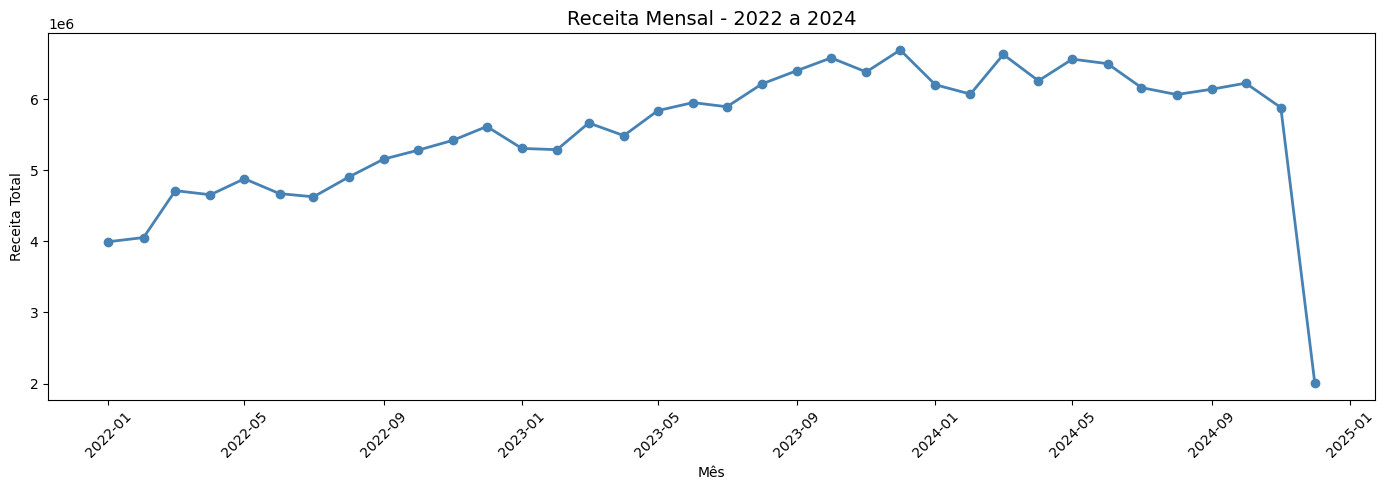

In [347]:
df_monthly_revenue['month'] = pd.to_datetime(df_monthly_revenue['month'])

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_monthly_revenue['month'], df_monthly_revenue['total_revenue'], marker='o', linewidth=2, color='steelblue')

ax.set_title('Receita Mensal - 2022 a 2024', fontsize=14)
ax.set_xlabel('Mês')
ax.set_ylabel('Receita Total')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#### Modelo de Regressão Linear para Forecast de 2025

In [353]:
df_clean = df_monthly_revenue[df_monthly_revenue['month'] < '2024-12'].copy()
df_clean = df_clean.reset_index(drop=True)
df_clean['month_index'] = range(len(df_clean))

# Modelo
X = df_clean[['month_index']]
y = df_clean['total_revenue']

model = LinearRegression()
model.fit(X, y)

print(f"R²: {model.score(X, y):.4f}")
print(f"Crescimento mensal estimado: R$ {model.coef_[0]:,.2f}")

# Projeta 12 meses de 2025
last_index = df_clean['month_index'].max()
future_indexes = np.array(range(last_index + 1, last_index + 13)).reshape(-1, 1)
projections = model.predict(future_indexes)

months_2025 = pd.date_range(start='2025-01', periods=12, freq='MS')
df_projection = pd.DataFrame({
    'month': months_2025,
    'projected_revenue': projections
})

print("\nProjeção 2025:")
print(df_projection.to_string(index=False))
print(f"\nTotal projetado 2025: R$ {projections.sum():,.2f}")
print(f"Total realizado 2024 (jan-nov): R$ {y[df_clean['month'].astype(str).str.startswith('2024')].sum():,.2f}")

R²: 0.7612
Crescimento mensal estimado: R$ 63,595.17

Projeção 2025:
     month  projected_revenue
2025-01-01       6.811800e+06
2025-02-01       6.875395e+06
2025-03-01       6.938990e+06
2025-04-01       7.002585e+06
2025-05-01       7.066180e+06
2025-06-01       7.129776e+06
2025-07-01       7.193371e+06
2025-08-01       7.256966e+06
2025-09-01       7.320561e+06
2025-10-01       7.384156e+06
2025-11-01       7.447751e+06
2025-12-01       7.511347e+06

Total projetado 2025: R$ 85,938,878.38
Total realizado 2024 (jan-nov): R$ 68,685,165.99


C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Visão de receita e streams por plataforma

#### Uso do DuckDB para leitura dos arquivos .gz

In [355]:
query = """
SELECT
column00 as store,
strftime(column01, '%Y-%m') as month,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2022_csv000.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_22_1 = duckdb.query(query).to_df()

query = """
SELECT
column00 as store,
strftime(column01, '%Y-%m') as month,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2022_csv001.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_22_2 = duckdb.query(query).to_df()

query = """
SELECT
column00 as store,
strftime(column01, '%Y-%m') as month,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2023_csv000.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_23_1 = duckdb.query(query).to_df()

query = """
SELECT
column00 as store,
strftime(column01, '%Y-%m') as month,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2023_csv001.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_23_2 = duckdb.query(query).to_df()

query = """
SELECT
column00 as store,
strftime(column01, '%Y-%m') as month,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2024_csv000.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_24_1 = duckdb.query(query).to_df()

query = """
SELECT
column00 as store,
strftime(column01, '%Y-%m') as month,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2024_csv001.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_24_2 = duckdb.query(query).to_df()

query = """
SELECT
column00 as store,
strftime(column01, '%Y-%m') as month,
sum(column03) as total_quantity,
sum(column06) as total_revenue
   
FROM read_csv_auto('C:/Users/Usuario/Documents/Case OneRPM/onerpm_data_analyst_test_data_2024_csv002.gz')

WHERE column04 = 1

GROUP BY 1,2
"""
result_24_3 = duckdb.query(query).to_df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

#### Comparação das plataformas por Revenue e Quantidade de Streams

In [374]:
df_store_revenue = pd.concat([result_22_1,result_22_2,result_23_1,result_23_2,result_24_1,result_24_2,result_24_3]).fillna(0)
df_store_revenue['year'] = df_store_revenue.month.apply(lambda x : x[:4])
df_store_revenue.replace([np.inf, -np.inf], np.nan, inplace=True)

df_store_revenue = df_store_revenue.groupby(['year','store'])[['total_quantity','total_revenue']].sum().reset_index()

df_store_revenue = df_store_revenue.merge(df_store_revenue.groupby('year')['total_quantity'].sum().reset_index().rename(columns={'total_quantity':'year_quantity'}))
df_store_revenue = df_store_revenue.merge(df_store_revenue.groupby('year')['total_revenue'].sum().reset_index().rename(columns={'total_revenue':'year_revenue'}))

df_store_revenue['store_quantity_share'] = df_store_revenue.total_quantity / df_store_revenue.year_quantity
df_store_revenue['store_revenue_share'] = df_store_revenue.total_revenue / df_store_revenue.year_revenue

df_store_revenue_22 = df_store_revenue[df_store_revenue.year == '2022'][['store','store_quantity_share','store_revenue_share']].rename(columns={'store_quantity_share':'store_quantity_share_22','store_revenue_share':'store_revenue_share_22'})
df_store_revenue_23 = df_store_revenue[df_store_revenue.year == '2023'][['store','store_quantity_share','store_revenue_share']].rename(columns={'store_quantity_share':'store_quantity_share_23','store_revenue_share':'store_revenue_share_23'})
df_store_revenue_24 = df_store_revenue[df_store_revenue.year == '2024'][['store','store_quantity_share','store_revenue_share']].rename(columns={'store_quantity_share':'store_quantity_share_24','store_revenue_share':'store_revenue_share_24'})

df_store_revenue_comparison = df_store_revenue_22.merge(df_store_revenue_23).merge(df_store_revenue_24)
df_store_revenue_comparison['quantity_year_variation_23'] = (df_store_revenue_comparison.store_quantity_share_23 / df_store_revenue_comparison.store_quantity_share_22)-1 
df_store_revenue_comparison['quantity_year_variation_24'] = (df_store_revenue_comparison.store_quantity_share_24 / df_store_revenue_comparison.store_quantity_share_23)-1
df_store_revenue_comparison['revenue_year_variation_23'] = (df_store_revenue_comparison.store_revenue_share_23 / df_store_revenue_comparison.store_revenue_share_22)-1
df_store_revenue_comparison['revenue_year_variation_24'] = (df_store_revenue_comparison.store_revenue_share_24 / df_store_revenue_comparison.store_revenue_share_23)-1

df_store_quantity_comparison = df_store_revenue_comparison[['store', 'store_quantity_share_22', 'store_quantity_share_23', 'store_quantity_share_24'
,'quantity_year_variation_23', 'quantity_year_variation_24']]
df_store_revenue_comparison = df_store_revenue_comparison[['store', 'store_revenue_share_22','store_revenue_share_23','store_revenue_share_24'
,'revenue_year_variation_23','revenue_year_variation_24']]

df_store_quantity_comparison = df_store_quantity_comparison.drop_duplicates()
df_store_revenue_comparison = df_store_revenue_comparison.drop_duplicates()

#### Atribuição de um score com base no share de quantidade de streams, revenue e variação anual

In [387]:
# Remover outliers na variação (percentil 95)
for col in ['quantity_year_variation_23', 'quantity_year_variation_24']:
    df_store_quantity_comparison[col] = df_store_quantity_comparison[col].clip(
        lower=df_store_quantity_comparison[col].quantile(0.05),
        upper=df_store_quantity_comparison[col].quantile(0.95))

for col in ['revenue_year_variation_23', 'revenue_year_variation_24']:
    df_store_revenue_comparison[col] = df_store_revenue_comparison[col].clip(
        lower=df_store_revenue_comparison[col].quantile(0.05),
        upper=df_store_revenue_comparison[col].quantile(0.95))

# Média de variação
df_store_quantity_comparison['quantity_variation_mean'] = (
    df_store_quantity_comparison['quantity_year_variation_23'] +
    df_store_quantity_comparison['quantity_year_variation_24']) / 2

df_store_revenue_comparison['revenue_variation_mean'] = (
    df_store_revenue_comparison['revenue_year_variation_23'] +
    df_store_revenue_comparison['revenue_year_variation_24']) / 2

scaler = MinMaxScaler()

# Score Quantidade
qty_features = ['store_quantity_share_24', 'quantity_variation_mean']
qty_weights  = [0.40, 0.60]

df_qty = df_store_quantity_comparison.copy()
df_qty[qty_features] = scaler.fit_transform(df_store_quantity_comparison[qty_features])
df_store_quantity_comparison['score_quantity'] = sum(df_qty[col] * w for col, w in zip(qty_features, qty_weights))

# Score Receita
rev_features = ['store_revenue_share_24', 'revenue_variation_mean']
rev_weights  = [0.40, 0.60]

df_rev = df_store_revenue_comparison.copy()
df_rev[rev_features] = scaler.fit_transform(df_store_revenue_comparison[rev_features])
df_store_revenue_comparison['score_revenue'] = sum(df_rev[col] * w for col, w in zip(rev_features, rev_weights))

# Merge
df_store_scores = df_store_quantity_comparison[['store', 'score_quantity']].merge(
    df_store_revenue_comparison[['store', 'score_revenue']],
    on=['store'])

# Score final combinado
df_store_scores['score_final'] = (df_store_scores['score_quantity'] * 0.4 +
                                     df_store_scores['score_revenue'] * 0.6)


In [386]:
df_store_revenue.sort_values(['store','year']).to_csv('C:/Users/Usuario/Documents/Case OneRPM/df_store_revenue.csv', index=False)

In [388]:
df_store_scores.sort_values('score_final',ascending = False)

,store,score_quantity,score_revenue,score_final
3,facebook_ugc_consumption,0.907626,0.648410,0.752096
8,youtube,0.405778,0.394910,0.399257
10,youtube_red,0.018970,0.405940,0.251152
5,spotify,0.048200,0.262309,0.176665
7,tiktok,0.011959,0.122934,0.078544
1,facebook_al_production,0.034761,0.104277,0.076470
2,facebook_revenue_share,0.027719,0.097295,0.069465
6,spotify_discovery,0.097099,0.027770,0.055501
11,youtube_red_adjustment,0.031143,0.062428,0.049914
9,youtube_adjustment,0.022213,0.059199,0.044405


#### Exportar CSVs para alimentar Dashboard

In [421]:
# 1. Receita mensal + projeção 2025
df_full.to_csv('C:/Users/Usuario/Documents/Case OneRPM/df_monthly_revenue.csv', index=False, decimal=',', sep=';')

# 2. Países com scores + quadrante crescimento/queda
df_country_scores.to_csv('C:/Users/Usuario/Documents/Case OneRPM/df_country_scores.csv', index=False, decimal=',', sep=';')

# 3. Plataformas com scores
df_store_scores.to_csv('C:/Users/Usuario/Documents/Case OneRPM/df_store_scores.csv', index=False, decimal=',', sep=';')

# 4. Gêneros com scores
result.to_csv('C:/Users/Usuario/Documents/Case OneRPM/genre_scores.csv', index=False, decimal=',', sep=';')

# 5. Comparação de países
df_country_revenue_comparison.to_csv('C:/Users/Usuario/Documents/Case OneRPM/df_country_revenue_comparison.csv', index=False, decimal=',', sep=';')
df_country_quantity_comparison.to_csv('C:/Users/Usuario/Documents/Case OneRPM/df_country_quantity_comparison.csv', index=False, decimal=',', sep=';')